In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, r2_score

import joblib

In [25]:
df = pd.read_csv(
    "/Users/aashishmewada/Desktop/PRISM AI/PRISM_AI/data/raw/CLV .csv"
)

In [26]:
df.head()

,CustomerID,Age,Gender,Income,Location,Membership,RegistrationDate,Tenure,TotalSpend,TotalTransactions,...,CustomerLifetimeValue,NextPurchaseAmount,NextPurchaseDays,DiscountUsed,CouponUsed,ReferralCount,PaymentMethod,DeviceType,ReturnRate,LoyaltyPoints
0,CUST-1001,58,Male,75927,Seattle,Basic,2024-11-15,19.5,3171.20,16,...,5959.50,185.95,41,0,0,1,Apple Pay,Mobile,0.05,31712
1,CUST-1002,66,Male,40538,Los Angeles,Basic,2024-04-14,26.5,12463.47,69,...,20844.34,204.44,6,37,5,2,Credit Card,Mobile,0.11,122784
2,CUST-1003,41,Male,99742,Philadelphia,Gold,2025-03-29,15.1,11819.42,34,...,17037.61,327.34,7,17,2,0,BNPL (Klarna/Afterpay),Desktop,0.08,176441
3,CUST-1004,59,Female,52220,Austin,Basic,2023-11-05,31.8,3657.69,27,...,7580.91,158.07,35,12,9,5,BNPL (Klarna/Afterpay),Mobile,0.14,35976
4,CUST-1005,18,Female,70323,Los Angeles,Gold,2022-08-05,46.8,7877.67,111,...,17058.40,84.22,13,47,10,0,BNPL (Klarna/Afterpay),Tablet,0.15,115815


In [27]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'Location', 'Membership',
       'RegistrationDate', 'Tenure', 'TotalSpend', 'TotalTransactions',
       'AverageOrderValue', 'PurchaseFrequency', 'LastPurchaseDays',
       'PreferredCategory', 'WebsiteVisits', 'AppUsageMinutes',
       'LoginFrequency', 'WishlistCount', 'CartAbandonmentRate',
       'EmailOpenRate', 'MarketingClicks', 'SatisfactionScore', 'Rating',
       'SupportCalls', 'Complaints', 'Reviews', 'CustomerHealthScore',
       'ChurnRisk', 'CustomerLifetimeValue', 'NextPurchaseAmount',
       'NextPurchaseDays', 'DiscountUsed', 'CouponUsed', 'ReferralCount',
       'PaymentMethod', 'DeviceType', 'ReturnRate', 'LoyaltyPoints'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             250 non-null    object 
 1   Age                    250 non-null    int64  
 2   Gender                 250 non-null    object 
 3   Income                 250 non-null    int64  
 4   Location               250 non-null    object 
 5   Membership             250 non-null    object 
 6   RegistrationDate       250 non-null    object 
 7   Tenure                 250 non-null    float64
 8   TotalSpend             250 non-null    float64
 9   TotalTransactions      250 non-null    int64  
 10  AverageOrderValue      250 non-null    float64
 11  PurchaseFrequency      250 non-null    float64
 12  LastPurchaseDays       250 non-null    int64  
 13  PreferredCategory      250 non-null    object 
 14  WebsiteVisits          250 non-null    int64  
 15  AppUsa

In [29]:
df["CLV"] = (
    df["AverageOrderValue"]
    *
    df["PurchaseFrequency"]
    *
    df["Tenure"]
)

In [30]:
df[["AverageOrderValue",
    "PurchaseFrequency",
    "Tenure",
    "CLV"]].head()

,AverageOrderValue,PurchaseFrequency,Tenure,CLV
0,198.20,0.82,19.5,3169.21800
1,180.63,2.60,26.5,12445.40700
2,347.63,2.25,15.1,11810.72925
3,135.47,0.85,31.8,3661.75410
4,70.97,2.37,46.8,7871.70852


In [31]:
df["CLV"].describe()

count      250.000000
mean     10867.161773
std       9896.595039
min        151.561410
25%       4098.022320
50%       7862.091780
75%      14975.990840
max      53894.631240
Name: CLV, dtype: float64

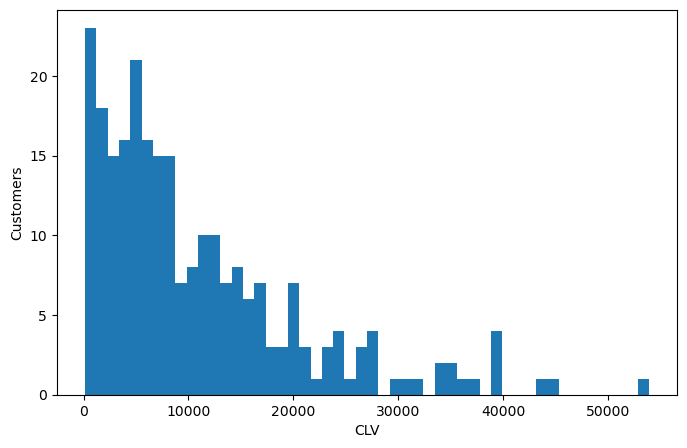

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    df["CLV"],
    bins=50
)

plt.xlabel("CLV")
plt.ylabel("Customers")

plt.show()

In [46]:
clv_features = [

"Income",

"Tenure",

"TotalSpend",

"TotalTransactions",

"AverageOrderValue",

"PurchaseFrequency",

"LastPurchaseDays",

"WebsiteVisits",

"AppUsageMinutes",

"LoginFrequency",

"WishlistCount",

"SatisfactionScore",

"Rating",

"CustomerHealthScore",

"SupportCalls",

"Complaints"

]

In [47]:
X = df[clv_features]


y = df["CLV"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [49]:
X_train.shape

(200, 16)

In [50]:
clv_pipeline = Pipeline(

steps=[

(
"imputer",
SimpleImputer(
strategy="median"
)
),


(
"scaler",
StandardScaler()
),


(
"model",
GradientBoostingRegressor(
random_state=42
)
)

]

)

In [51]:
clv_pipeline.fit(

X_train,

y_train

)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Income','Tenure','TotalSpend',...,'CustomerHealthScore','SupportCalls', 'Complaints']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or o

In [52]:
prediction = clv_pipeline.predict(

X_test

)

In [53]:
mae = mean_absolute_error(

y_test,

prediction

)


mae

327.53976239909645

In [54]:
r2 = r2_score(

y_test,

prediction

)


r2

0.9921279342670448

In [55]:
test_model = joblib.load(

"../models/clv_pipeline.pkl"

)

In [56]:
test_model.predict(
    X_test.iloc[:1]
)

array([17115.12713978])

In [58]:
import joblib


joblib.dump(
    clv_model,
    "/models/clv_model.pkl"
)


joblib.dump(
    scaler,
    "../models/clv_scaler.pkl"
)

NameError: name 'clv_model' is not defined